In [2]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

In [3]:
!pip install pandas_ta

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.1/115.1 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pandas_ta: filename=pandas_ta-0.3.14b0-py3-none-any.whl size=218909 sha256=58821450afa22649852232a1d85a32d00139edcb11c45aeaf2672ffbe0556398
  Stored in directory: /root/.cache/pip/wheels/7f/33/8b/50b245c5c65433cd8f5cb24ac15d97e5a3db2d41a8b6ae957d
Successfully built pandas_ta


In [4]:
data = pd.read_csv('/kaggle/input/eurusd60/EURUSD-60-DS-redate.csv')
data.head()

,Date,Open,High,Low,Close,Volume
0,15.08.2017 00:00:00.000,1.17786,1.17812,1.17750,1.17759,6070.48
1,15.08.2017 01:00:00.000,1.17759,1.17802,1.17752,1.17783,3163.99
2,15.08.2017 02:00:00.000,1.17783,1.17802,1.17682,1.17755,4086.81
3,15.08.2017 03:00:00.000,1.17757,1.17895,1.17751,1.17811,6937.33
4,15.08.2017 04:00:00.000,1.17812,1.17928,1.17812,1.17855,7265.10


In [5]:
import pandas_ta as ta
data['RSI'] = ta.rsi(data['Close'], length=14)
data['sma10'] = ta.sma(data['Close'], length=10)
data['sma50'] = ta.sma(data['Close'], length=50)
macd = ta.macd(data['Close'], fast=12, slow=26, signal=9)
data['macd_line'] = macd['MACD_12_26_9']
data['macd_signal'] = macd['MACDs_12_26_9']
data['macd_diff'] = data['macd_line'] - data['macd_signal']
data.dropna(inplace=True)

data['sma_diff'] = data['sma50'] - data['sma10']

data.head()

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


,Date,Open,High,Low,Close,Volume,RSI,sma10,sma50,macd_line,macd_signal,macd_diff,sma_diff
49,17.08.2017 01:00:00.000,1.17712,1.17793,1.17705,1.17776,3865.97,67.299652,1.173869,1.174137,0.000717,-0.000183,0.000900,0.000268
50,17.08.2017 02:00:00.000,1.17772,1.17791,1.17698,1.17737,3134.37,65.033882,1.174659,1.174132,0.000880,0.000030,0.000850,-0.000527
51,17.08.2017 03:00:00.000,1.17737,1.17745,1.17649,1.17679,6088.52,61.706650,1.175311,1.174112,0.000950,0.000214,0.000736,-0.001199
52,17.08.2017 04:00:00.000,1.17679,1.17888,1.17669,1.17885,9345.45,67.973832,1.176179,1.174138,0.001159,0.000403,0.000756,-0.002041
53,17.08.2017 05:00:00.000,1.17885,1.17899,1.17775,1.17824,7011.27,64.602175,1.176989,1.174140,0.001261,0.000575,0.000686,-0.002849


In [6]:
# # فرض می‌کنیم داده‌ها در data موجود هستند و شامل Close, RSI, sma10, sma50, macd_line, macd_signal است

# سیگنال اولیه
data['signal'] = 'hold'

# شرایط خرید و فروش فعلی
sell_condition_1 = data['RSI'] > 70
buy_condition_2 = (data['sma10'] > data['sma50']) & (data['sma10'].shift(1) <= data['sma50'].shift(1))  # تقاطع صعودی
buy_condition_1 = data['RSI'] < 30
sell_condition_2 = (data['sma10'] < data['sma50']) & (data['sma10'].shift(1) >= data['sma50'].shift(1))  # تقاطع نزولی
buy_condition_macd = (data['macd_line'] > data['macd_signal']) & (data['macd_line'].shift(1) <= data['macd_signal'].shift(1))
sell_condition_macd = (data['macd_line'] < data['macd_signal']) & (data['macd_line'].shift(1) >= data['macd_signal'].shift(1))

# # واگرایی‌های RSI
# window = 7
# data['price_lower_low'] = (data['Close'] < data['Close'].shift(1)) & (data['Close'] == data['Close'].rolling(window, center=True).min())
# data['rsi_lower_low'] = (data['RSI'] < data['RSI'].shift(1)) & (data['RSI'] == data['RSI'].rolling(window, center=True).min())
# data['price_higher_high'] = (data['Close'] > data['Close'].shift(1)) & (data['Close'] == data['Close'].rolling(window, center=True).max())
# data['rsi_higher_high'] = (data['RSI'] > data['RSI'].shift(1)) & (data['RSI'] == data['RSI'].rolling(window, center=True).max())
# buy_condition_divergence = (data['price_lower_low'] == True) & (data['RSI'] > data['RSI'].shift(1))
# sell_condition_divergence = (data['price_higher_high'] == True) & (data['RSI'] < data['RSI'].shift(1))

# # واگرایی‌های MACD
# data['macd_lower_low'] = (data['macd_line'] < data['macd_line'].shift(1)) & (data['macd_line'] == data['macd_line'].rolling(window, center=True).min())
# data['macd_higher_high'] = (data['macd_line'] > data['macd_line'].shift(1)) & (data['macd_line'] == data['macd_line'].rolling(window, center=True).max())
# buy_condition_macd_divergence = (data['price_lower_low'] == True) & (data['macd_line'] > data['macd_line'].shift(1))
# sell_condition_macd_divergence = (data['price_higher_high'] == True) & (data['macd_line'] < data['macd_line'].shift(1))

# # سیگنال مبتنی بر انحراف معیار
# window_std = 20
# data['sma20'] = data['Close'].rolling(window=window_std).mean()
# data['std20'] = data['Close'].rolling(window=window_std).std()
# data['upper_band'] = data['sma20'] + (2 * data['std20'])
# data['lower_band'] = data['sma20'] - (2 * data['std20'])
# buy_condition_std = data['Close'] < data['lower_band']
# sell_condition_std = data['Close'] > data['upper_band']

# به‌روزرسانی سیگنال‌ها
data.loc[buy_condition_1 | buy_condition_2 | buy_condition_macd , 'signal'] = 'buy'
data.loc[sell_condition_1 | sell_condition_2 | sell_condition_macd , 'signal'] = 'sell'

# نمایش 10 ردیف اول
data.head(10)

# data['signal'] = 'hold'

# # شرایط خرید و فروش
# sell_condition_1 = data['RSI'] > 80  # تنظیم آستانه
# buy_condition_2 = (data['sma10'] > data['sma50']) & (data['sma10'].shift(1) <= data['sma50'].shift(1))
# buy_condition_1 = data['RSI'] < 20
# sell_condition_2 = (data['sma10'] < data['sma50']) & (data['sma10'].shift(1) >= data['sma50'].shift(1))
# buy_condition_macd = (data['macd_line'] > data['macd_signal']) & (data['macd_line'].shift(1) <= data['macd_signal'].shift(1))
# sell_condition_macd = (data['macd_line'] < data['macd_signal']) & (data['macd_line'].shift(1) >= data['macd_signal'].shift(1))

# # واگرایی‌ها
# window = 14  # افزایش دوره برای کاهش نویز
# data['price_lower_low'] = (data['Close'] < data['Close'].shift(1)) & (data['Close'] == data['Close'].rolling(window, center=True).min())
# data['rsi_lower_low'] = (data['RSI'] < data['RSI'].shift(1)) & (data['RSI'] == data['RSI'].rolling(window, center=True).min())
# data['price_higher_high'] = (data['Close'] > data['Close'].shift(1)) & (data['Close'] == data['Close'].rolling(window, center=True).max())
# data['rsi_higher_high'] = (data['RSI'] > data['RSI'].shift(1)) & (data['RSI'] == data['RSI'].rolling(window, center=True).max())
# buy_condition_divergence = (data['price_lower_low'] == True) & (data['RSI'] > data['RSI'].shift(1))
# sell_condition_divergence = (data['price_higher_high'] == True) & (data['RSI'] < data['RSI'].shift(1))

# data['macd_lower_low'] = (data['macd_line'] < data['macd_line'].shift(1)) & (data['macd_line'] == data['macd_line'].rolling(window, center=True).min())
# data['macd_higher_high'] = (data['macd_line'] > data['macd_line'].shift(1)) & (data['macd_line'] == data['macd_line'].rolling(window, center=True).max())
# buy_condition_macd_divergence = (data['price_lower_low'] == True) & (data['macd_line'] > data['macd_line'].shift(1))
# sell_condition_macd_divergence = (data['price_higher_high'] == True) & (data['macd_line'] < data['macd_line'].shift(1))

# # انحراف معیار
# window_std = 20
# data['sma20'] = data['Close'].rolling(window=window_std).mean()
# data['std20'] = data['Close'].rolling(window=window_std).std()
# data['upper_band'] = data['sma20'] + (2 * data['std20'])
# data['lower_band'] = data['sma20'] - (2 * data['std20'])
# buy_condition_std = data['Close'] < data['lower_band']
# sell_condition_std = data['Close'] > data['upper_band']

# # سیستم امتیازدهی
# data['buy_score'] = 0
# data.loc[buy_condition_1, 'buy_score'] += 1
# data.loc[buy_condition_2, 'buy_score'] += 1
# data.loc[buy_condition_macd, 'buy_score'] += 1
# data.loc[buy_condition_divergence, 'buy_score'] += 2
# data.loc[buy_condition_macd_divergence, 'buy_score'] += 2
# data.loc[buy_condition_std, 'buy_score'] += 1

# data['sell_score'] = 0
# data.loc[sell_condition_1, 'sell_score'] += 1
# data.loc[sell_condition_2, 'sell_score'] += 1
# data.loc[sell_condition_macd, 'sell_score'] += 1
# data.loc[sell_condition_divergence, 'sell_score'] += 2
# data.loc[sell_condition_macd_divergence, 'sell_score'] += 2
# data.loc[sell_condition_std, 'sell_score'] += 1


# # اعمال سیگنال‌ها با فیلتر
# data.loc[(data['buy_score'] >= 2) | ((data['RSI'] < 20)), 'signal'] = 'buy'
# data.loc[(data['sell_score'] >= 2) | ((data['RSI'] > 80)), 'signal'] = 'sell'

# data.head()

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater_equal
  return op(a, b)


,Date,Open,High,Low,Close,Volume,RSI,sma10,sma50,macd_line,macd_signal,macd_diff,sma_diff,signal
49,17.08.2017 01:00:00.000,1.17712,1.17793,1.17705,1.17776,3865.97,67.299652,1.173869,1.174137,0.000717,-0.000183,0.000900,0.000268,hold
50,17.08.2017 02:00:00.000,1.17772,1.17791,1.17698,1.17737,3134.37,65.033882,1.174659,1.174132,0.000880,0.000030,0.000850,-0.000527,buy
51,17.08.2017 03:00:00.000,1.17737,1.17745,1.17649,1.17679,6088.52,61.706650,1.175311,1.174112,0.000950,0.000214,0.000736,-0.001199,hold
52,17.08.2017 04:00:00.000,1.17679,1.17888,1.17669,1.17885,9345.45,67.973832,1.176179,1.174138,0.001159,0.000403,0.000756,-0.002041,hold
53,17.08.2017 05:00:00.000,1.17885,1.17899,1.17775,1.17824,7011.27,64.602175,1.176989,1.174140,0.001261,0.000575,0.000686,-0.002849,hold
54,17.08.2017 06:00:00.000,1.17823,1.17832,1.17747,1.17775,5895.31,61.944186,1.177430,1.174124,0.001287,0.000717,0.000570,-0.003306,hold
55,17.08.2017 07:00:00.000,1.17774,1.17819,1.17773,1.17791,4442.17,62.486933,1.177538,1.174117,0.001306,0.000835,0.000471,-0.003421,hold
56,17.08.2017 08:00:00.000,1.17792,1.17896,1.17757,1.17789,6395.19,62.367196,1.177634,1.174111,0.001304,0.000929,0.000375,-0.003523,hold
57,17.08.2017 09:00:00.000,1.17789,1.17801,1.17628,1.17631,10449.30,53.625063,1.177600,1.174082,0.001162,0.000975,0.000186,-0.003518,hold
58,17.08.2017 10:00:00.000,1.17631,1.17656,1.17509,1.17562,11997.40,50.308565,1.177449,1.174074,0.000982,0.000977,0.000005,-0.003375,hold


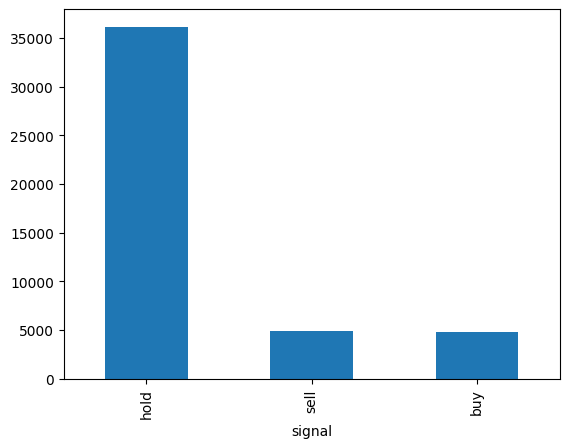

In [7]:
import matplotlib.pyplot as plt
data['signal'].value_counts().plot(kind='bar')
plt.show()

In [8]:
data['signal'].value_counts()

signal
hold    36153
sell     4901
buy      4762
Name: count, dtype: int64

In [9]:
data['signal'] = data['signal'].map({'buy': 1, 'sell': -1, 'hold': 0})

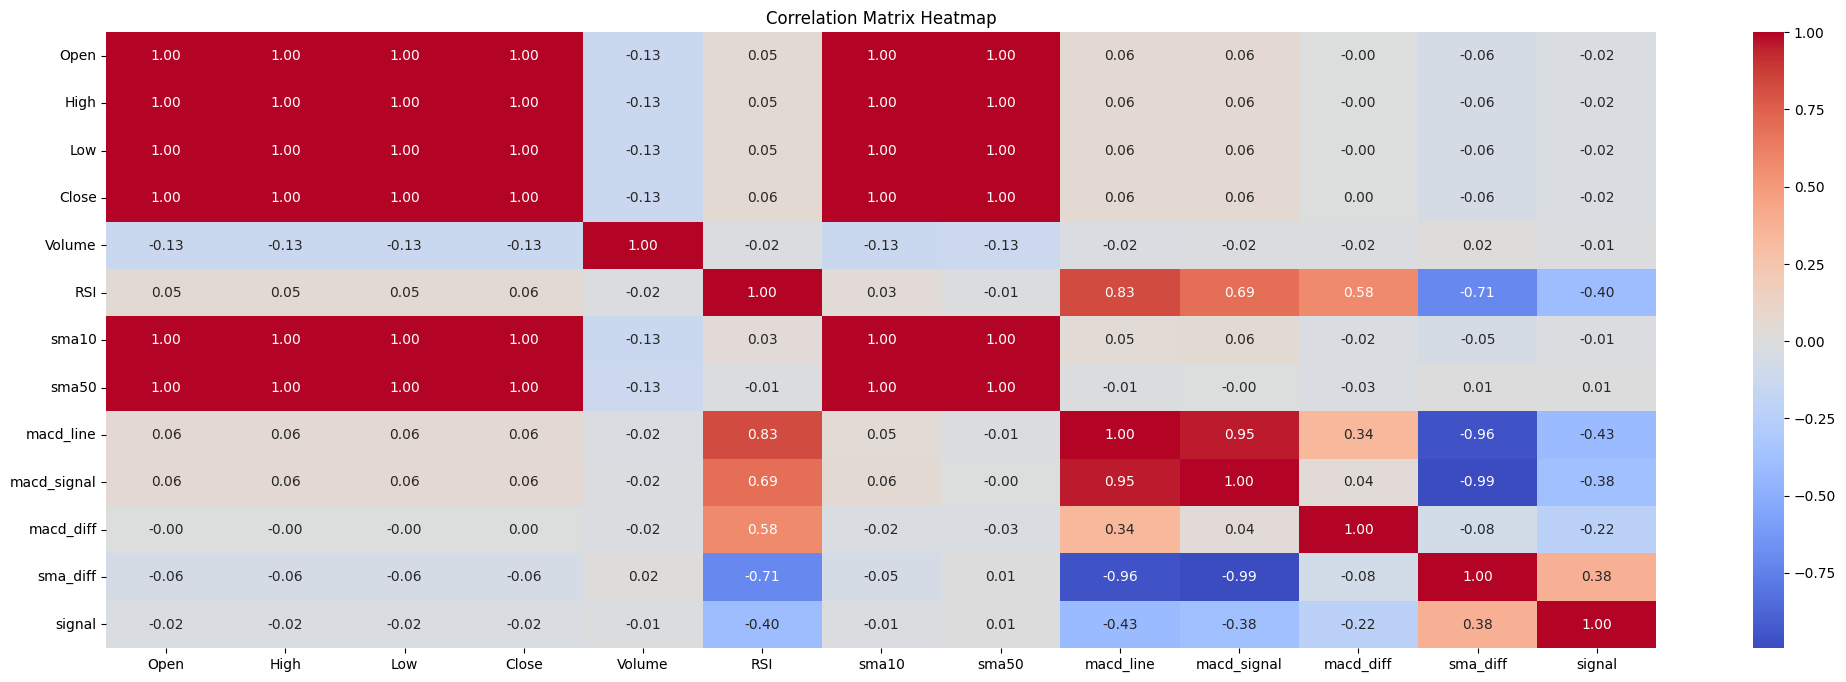

In [10]:
import seaborn as sns
correlation_matrix = data.drop(['Date'],axis=1).corr()
plt.figure(figsize=(25, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

In [11]:
features = ['Close', 'RSI', 'sma10', 'sma50', 'macd_line', 'macd_signal', 'ema_diff', 'macd_diff']
# features = ['RSI', 'sma10', 'sma50']
X = data[features]
y = data['signal']

# تقسیم داده‌ها به مجموعه آموزش و تست (80% آموزش، 20% تست)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=False)

KeyError: "['ema_diff'] not in index"

In [21]:
del dt_model

In [22]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [23]:
y_pred = dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Sell (-1)', 'Hold (0)', 'Buy (1)']))

Accuracy: 0.8354

Classification Report:
              precision    recall  f1-score   support

   Sell (-1)       0.59      0.59      0.59       915
    Hold (0)       0.90      0.90      0.90      7296
     Buy (1)       0.58      0.59      0.58       953

    accuracy                           0.84      9164
   macro avg       0.69      0.69      0.69      9164
weighted avg       0.84      0.84      0.84      9164



In [18]:
# نمایش اهمیت ویژگی‌ها
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print("\nFeature Importance:")
print(feature_importance)


Feature Importance:
       Feature  Importance
1          RSI    0.624231
7    macd_diff    0.124591
4    macd_line    0.095072
6     ema_diff    0.076877
5  macd_signal    0.037075
3        ema50    0.015376
2        ema20    0.013747
0        Close    0.013031


Decision tree visualization saved as 'decision_tree.png'


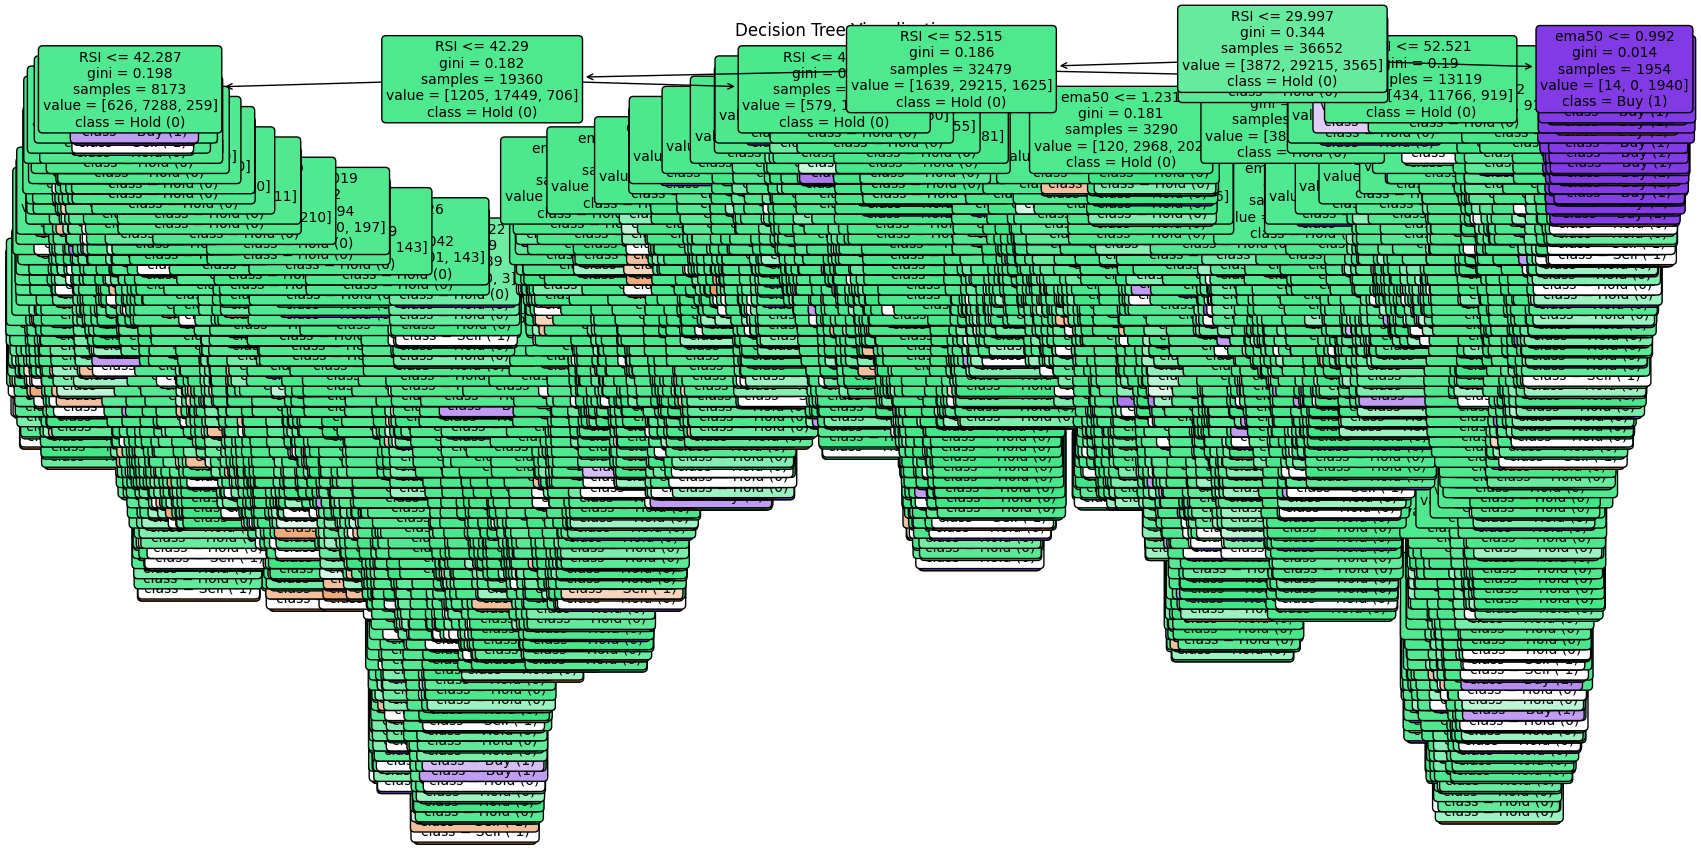

In [24]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(dt_model, 
          feature_names=features, 
          class_names=['Sell (-1)', 'Hold (0)', 'Buy (1)'], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.title('Decision Tree Visualization')
plt.savefig('decision_tree0.png')
print("Decision tree visualization saved as 'decision_tree.png'")

In [12]:
data.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'RSI', 'sma10',
       'sma50', 'macd_line', 'macd_signal', 'macd_diff', 'sma_diff', 'signal',
       'price_lower_low', 'rsi_lower_low', 'price_higher_high',
       'rsi_higher_high', 'macd_lower_low', 'macd_higher_high', 'sma20',
       'std20', 'upper_band', 'lower_band'],
      dtype='object')

In [12]:
features = ['Close', 'RSI', 'sma10', 'sma50', 'macd_line', 'macd_signal', 'sma_diff', 'macd_diff']

X = data[features]
y = data['signal']

In [13]:
y_mapped = y.map({-1: 0, 0: 1, 1: 2})  # -1 -> 0 (Sell), 0 -> 1 (Hold), 1 -> 2 (Buy)

# تقسیم داده‌ها به مجموعه آموزش و تست
X_train, X_test, y_train, y_test = train_test_split(X, y_mapped, test_size=0.2, random_state=42)

In [18]:
del xgb_model

In [14]:
import xgboost as xgb
xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=3, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=3,
              num_parallel_tree=None, ...)

In [15]:
y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Sell (-1)', 'Hold (0)', 'Buy (1)']))

Accuracy: 0.9488

Classification Report:
              precision    recall  f1-score   support

   Sell (-1)       0.89      0.82      0.86       939
    Hold (0)       0.96      0.98      0.97      7232
     Buy (1)       0.91      0.84      0.88       993

    accuracy                           0.95      9164
   macro avg       0.92      0.88      0.90      9164
weighted avg       0.95      0.95      0.95      9164



In [16]:
# نمایش اهمیت ویژگی‌ها
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print("\nFeature Importance:")
print(feature_importance)


Feature Importance:
       Feature  Importance
1          RSI    0.512085
7    macd_diff    0.165809
6     sma_diff    0.140348
4    macd_line    0.070680
5  macd_signal    0.043253
2        sma10    0.023065
0        Close    0.023050
3        sma50    0.021711


XGBoost tree visualization saved as 'xgboost_tree3.png'


<Figure size 5000x1000 with 0 Axes>

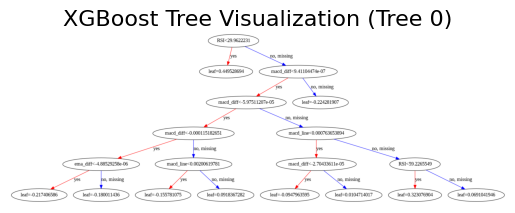

In [33]:
plt.figure(figsize=(50, 10))
xgb.plot_tree(xgb_model, num_trees=0, rankdir='TB')  # افزایش اندازه فونت
plt.title('XGBoost Tree Visualization (Tree 0)', fontsize=16)
plt.savefig('xgboost_tree3.png', dpi=300, bbox_inches='tight')  # افزایش DPI و تنظیم حاشیه
print("XGBoost tree visualization saved as 'xgboost_tree3.png'")

In [8]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
from tqdm import tqdm

# تعریف ویژگی‌ها و داده‌ها
features = ['Close', 'RSI', 'sma10', 'sma50', 'macd_line', 'macd_signal', 'ema_diff', 'macd_diff']
X = data[features]
y = data['signal']

# تبدیل برچسب‌ها به مقادیر غیرمنفی (0, 1, 2) برای XGBoost
y_mapped = y.map({-1: 0, 0: 1, 1: 2})  # -1 -> 0 (Sell), 0 -> 1 (Hold), 1 -> 2 (Buy)

# تقسیم داده‌ها به مجموعه آموزش و تست
X_train, X_test, y_train, y_test = train_test_split(X, y_mapped, test_size=0.2, random_state=42)

# تعریف مدل پایه XGBoost با پشتیبانی از GPU
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    device='cuda'  # استفاده از GPU (برای نسخه‌های قدیمی‌تر از tree_method='gpu_hist' استفاده کن)
)

# تعریف شبکه پارامترها برای جستجو
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [50, 100, 200],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# تنظیم GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='accuracy',  # معیار بهینه‌سازی: دقت
    cv=5,  # تعداد فولدهای اعتبارسنجی متقاطع
    verbose=0,  # خاموش کردن verbose پیش‌فرض
    n_jobs=-1  # استفاده از تمام هسته‌های CPU برای سرعت بیشتر
)

# محاسبه تعداد کل ترکیب‌ها
n_combinations = 1
for key in param_grid:
    n_combinations *= len(param_grid[key])
n_combinations *= 5  # ضرب در تعداد فولدها (cv=5)

# اجرای GridSearchCV با نوار پیشرفت tqdm
with tqdm(total=n_combinations, desc="GridSearchCV Progress") as pbar:
    def callback(*args, **kwargs):
        pbar.update(1)
    # تابع fit رو با callback اجرا می‌کنیم
    grid_search.fit(X_train, y_train)
    pbar.update(n_combinations - pbar.n)  # مطمئن می‌شیم که نوار به 100% برسه

# نمایش بهترین پارامترها و دقت
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy (on validation set):", grid_search.best_score_)

# استفاده از بهترین مدل برای پیش‌بینی
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# ارزیابی مدل روی داده‌های تست
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy on Test Set: {accuracy:.4f}")
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_pred, target_names=['Sell (0)', 'Hold (1)', 'Buy (2)']))

GridSearchCV Progress:   0%|          | 0/1215 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [09:46:01] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [09:46:01] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matc

Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.3, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Best Accuracy (on validation set): 0.9575739049799363
Accuracy on Test Set: 0.9570

Classification Report on Test Set:
              precision    recall  f1-score   support

    Sell (0)       0.93      0.86      0.89      1003
    Hold (1)       0.96      0.98      0.97      7295
     Buy (2)       0.92      0.85      0.88       866

    accuracy                           0.96      9164
   macro avg       0.94      0.90      0.92      9164
weighted avg       0.96      0.96      0.96      9164




/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [10:17:02] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


In [9]:
import pickle
with open('best_xgboost_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print("Model saved as 'best_xgboost_model.pkl' using pickle")

Model saved as 'best_xgboost_model.pkl' using pickle


In [19]:
import pandas as pd
import pandas_ta as ta
import numpy as np
import pickle
import matplotlib.pyplot as plt

def test_model_and_plot(csv_path):
    # خواندن دیتاست از فایل CSV
    data = pd.read_csv(csv_path)

    # # محاسبه ویژگی‌ها
    # data['RSI'] = ta.rsi(data['Close'], length=14)
    # data['sma10'] = ta.ema(data['Close'], length=20)
    # data['sma50'] = ta.ema(data['Close'], length=50)
    # macd = ta.macd(data['Close'], fast=12, slow=26, signal=9)
    # data['macd_line'] = macd['MACD_12_26_9']
    # data['macd_signal'] = macd['MACDs_12_26_9']
    # data['ema_diff'] = data['sma50'] - data['sma10']
    # data['macd_diff'] = data['macd_line'] - data['macd_signal']
    data['RSI'] = ta.rsi(data['Close'], length=14)
    data['sma10'] = ta.sma(data['Close'], length=10)
    data['sma50'] = ta.sma(data['Close'], length=50)
    macd = ta.macd(data['Close'], fast=12, slow=26, signal=9)
    data['macd_line'] = macd['MACD_12_26_9']
    data['macd_signal'] = macd['MACDs_12_26_9']
    data['macd_diff'] = data['macd_line'] - data['macd_signal']
    
    
    data['sma_diff'] = data['sma50'] - data['sma10']

    data['sma20'] = data['Close'].rolling(window=window_std).mean()
    data['std20'] = data['Close'].rolling(window=window_std).std()
    data['upper_band'] = data['sma20'] + (2 * data['std20'])
    data['lower_band'] = data['sma20'] - (2 * data['std20'])

    data.dropna(inplace=True)
    features = [
        'Close', 'RSI', 'sma10', 'sma50', 'macd_line', 'macd_signal', 
        'macd_diff', 'sma_diff', 'sma20', 'std20', 'upper_band', 'lower_band'
    ]
    # تعریف ویژگی‌های ورودی
    # features = ['Close', 'RSI', 'sma10', 'sma50', 'macd_line', 'macd_signal', 'ema_diff', 'macd_diff']
    X = data[features]

    # بارگذاری مدل
    # with open('best_xgboost_model.pkl', 'rb') as f:
    #     model = pickle.load(f)

    # پیش‌بینی سیگنال‌ها
    data['predicted_signal'] = xgb_model.predict(X)

    # انتخاب 5 دسته 100تایی متوالی به صورت رندوم
    max_start = len(data) - 100
    random_starts = np.random.choice(range(max_start), size=5, replace=False)

    # رسم 5 نمودار
    for i, start in enumerate(random_starts):
        end = start + 100
        subset = data.iloc[start:end]

        # رسم لاین‌پلات برای Close
        plt.figure(figsize=(10, 6))
        plt.plot(subset.index, subset['Close'], label='Close Price', color='black', linewidth=1)

        # رسم سیگنال‌ها با مثلث
        buy_signals = subset[subset['predicted_signal'] == 2]  # Buy
        hold_signals = subset[subset['predicted_signal'] == 1]  # Hold
        sell_signals = subset[subset['predicted_signal'] == 0]  # Sell

        plt.scatter(buy_signals.index, buy_signals['Close'], marker='^', color='green', label='Buy', s=100)
        # plt.scatter(hold_signals.index, hold_signals['Close'], marker='^', color='blue', label='Hold', s=100)
        plt.scatter(sell_signals.index, sell_signals['Close'], marker='^', color='red', label='Sell', s=100)

        # تنظیمات نمودار
        plt.title(f'Close Price and Predicted Signals (Sample {i+1})')
        plt.xlabel('Index')
        plt.ylabel('Close Price')
        plt.legend()
        plt.grid(True)
        plt.show()

    print("Plots saved as 'signal_plot_1.png' to 'signal_plot_5.png'")

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


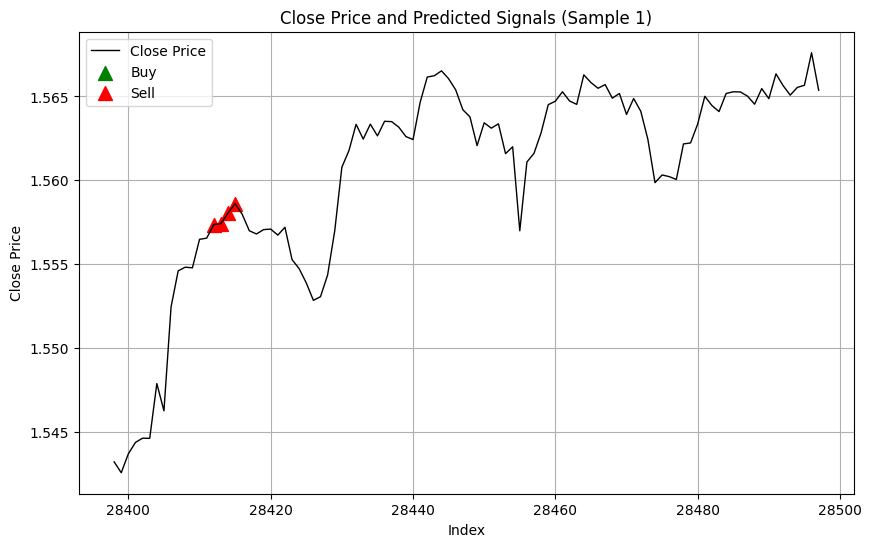

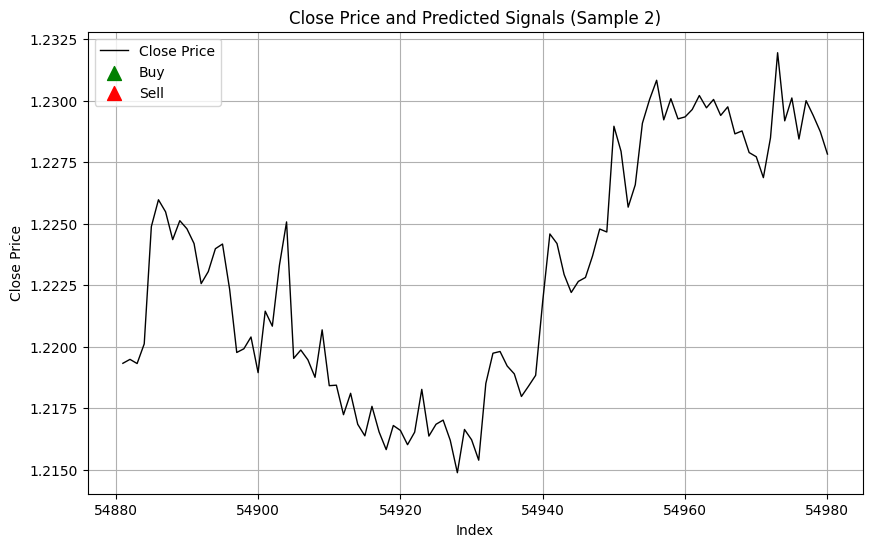

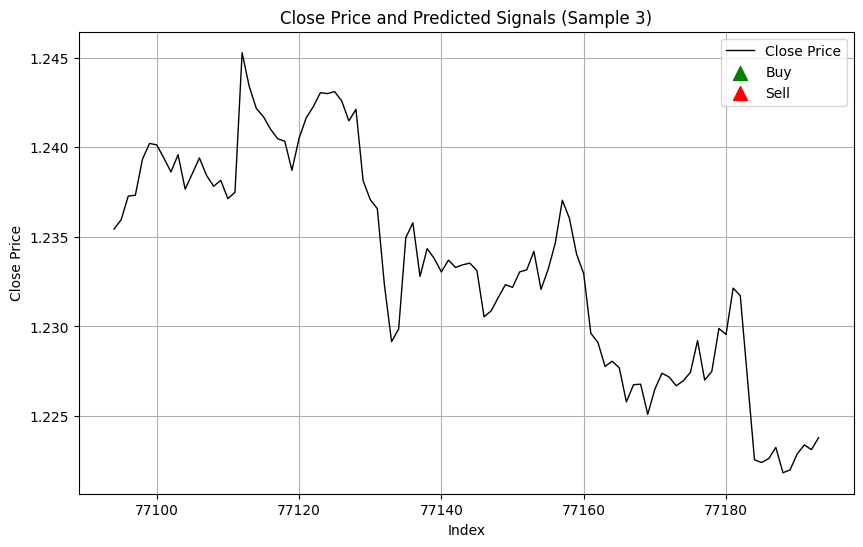

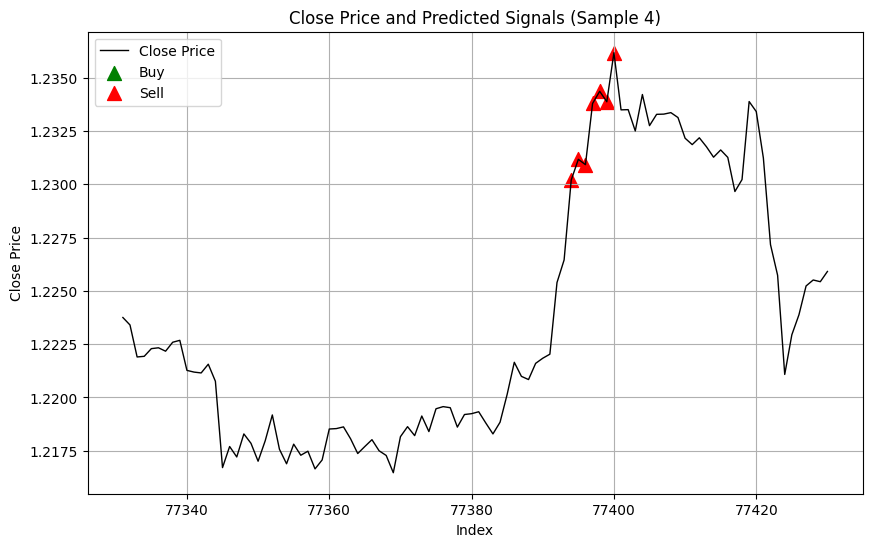

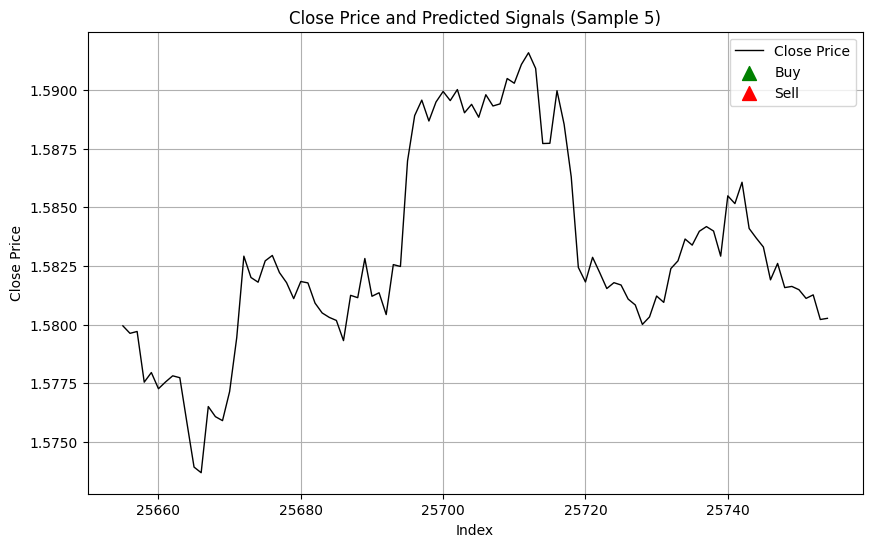

Plots saved as 'signal_plot_1.png' to 'signal_plot_5.png'


In [20]:
test_model_and_plot('/kaggle/input/testingg/GBPUSD-60-DS.csv')

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


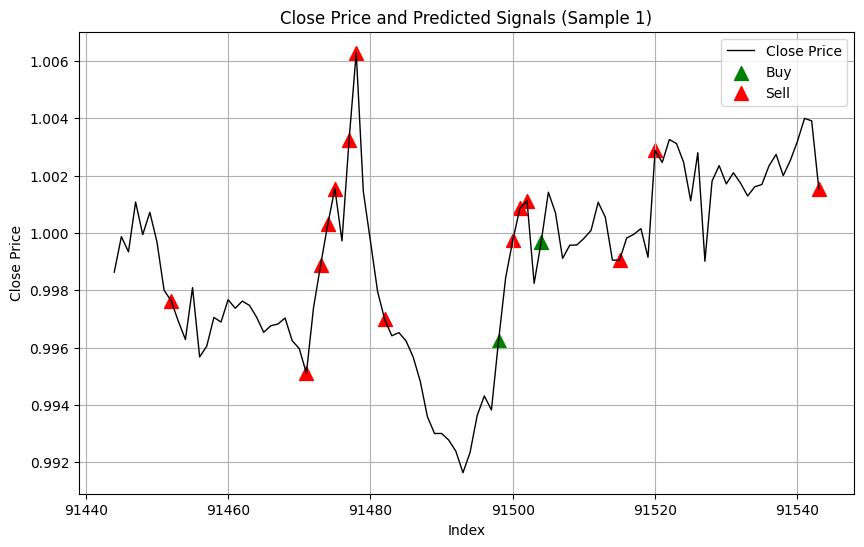

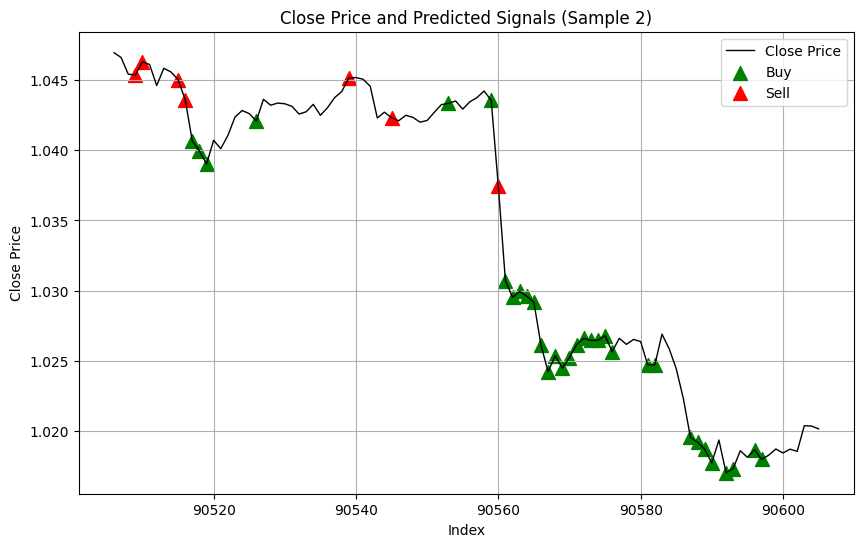

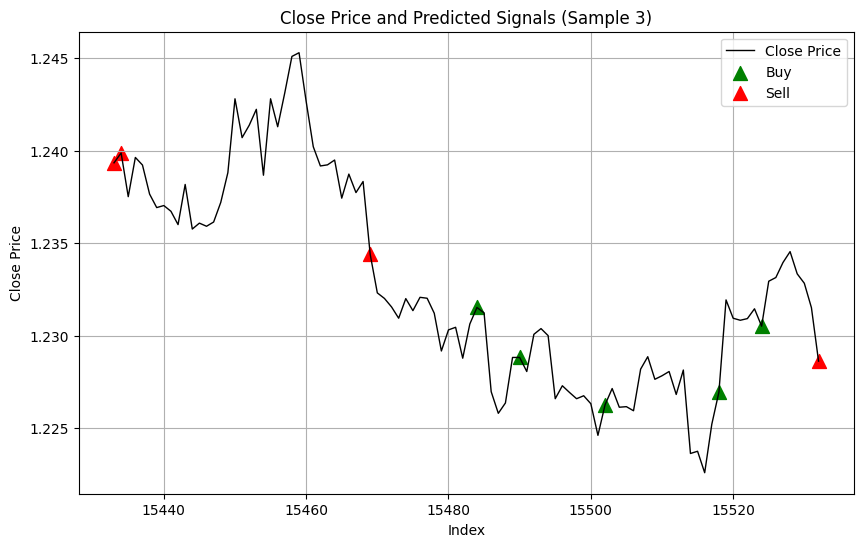

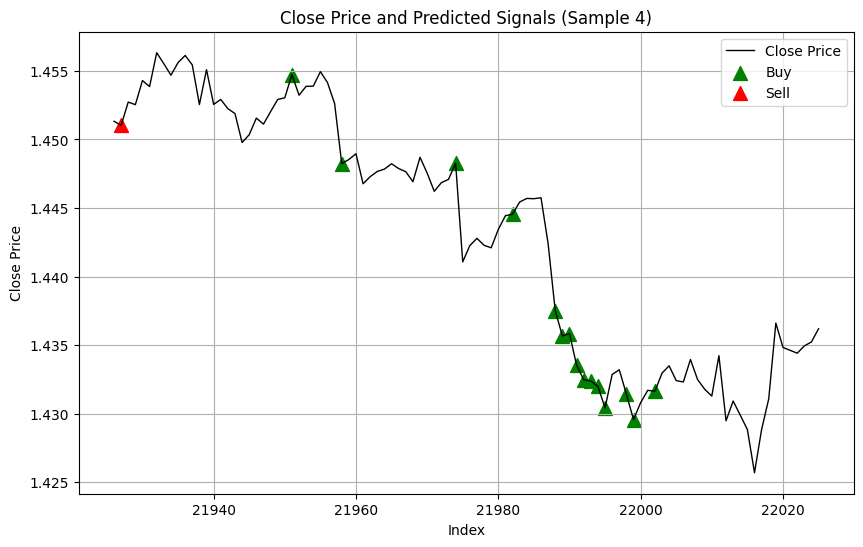

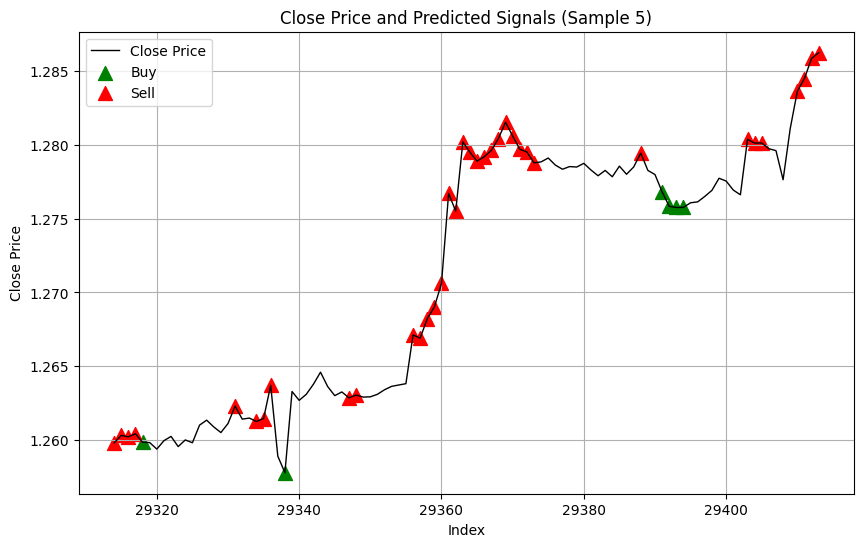

Plots saved as 'signal_plot_1.png' to 'signal_plot_5.png'


In [18]:
test_model_and_plot('/kaggle/input/eurusd60/EURUSD-60-DS.csv')

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


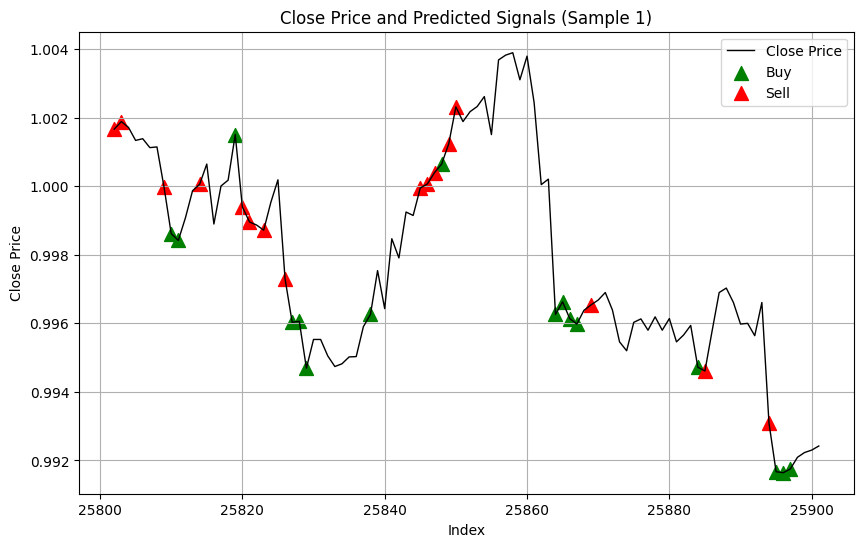

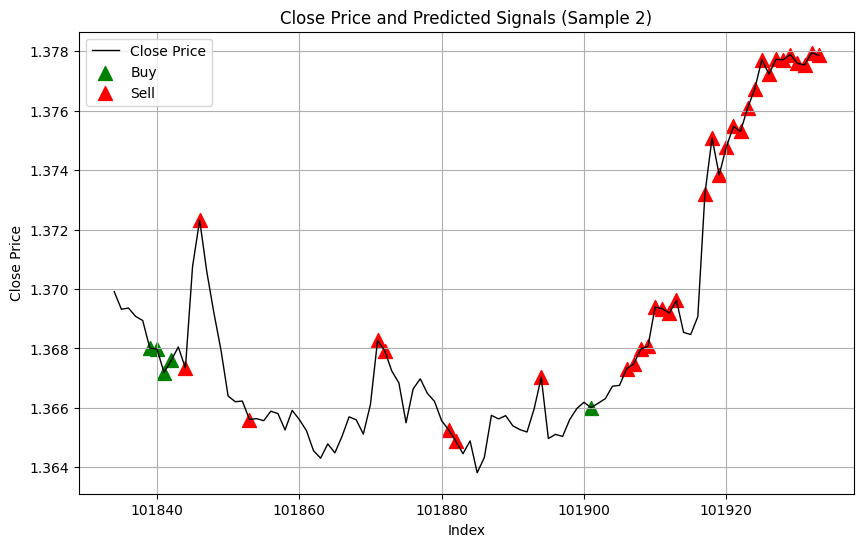

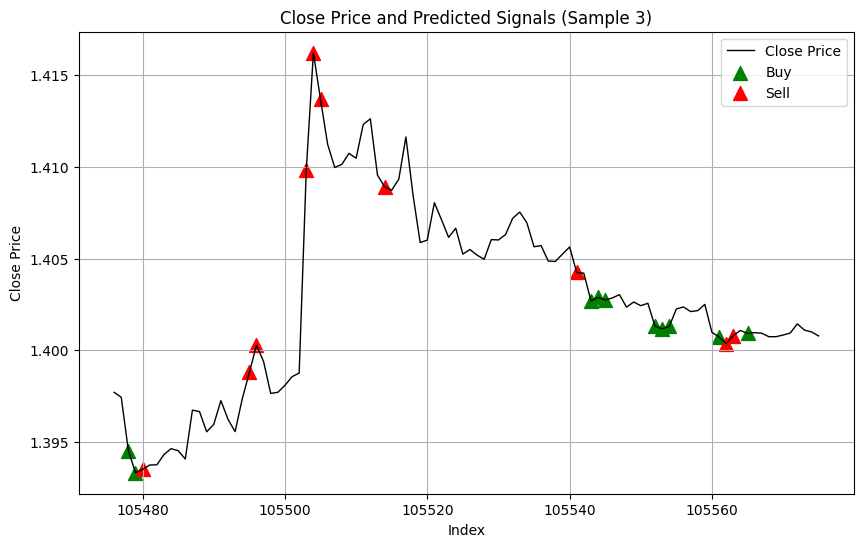

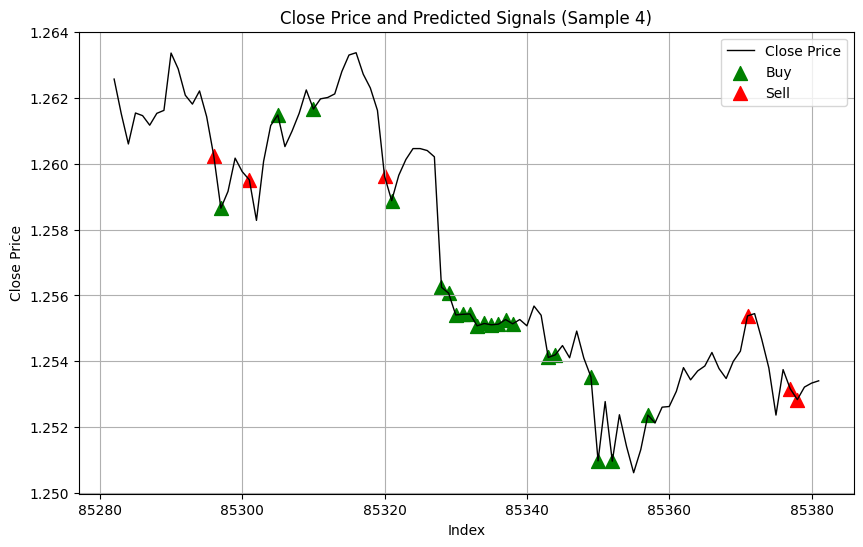

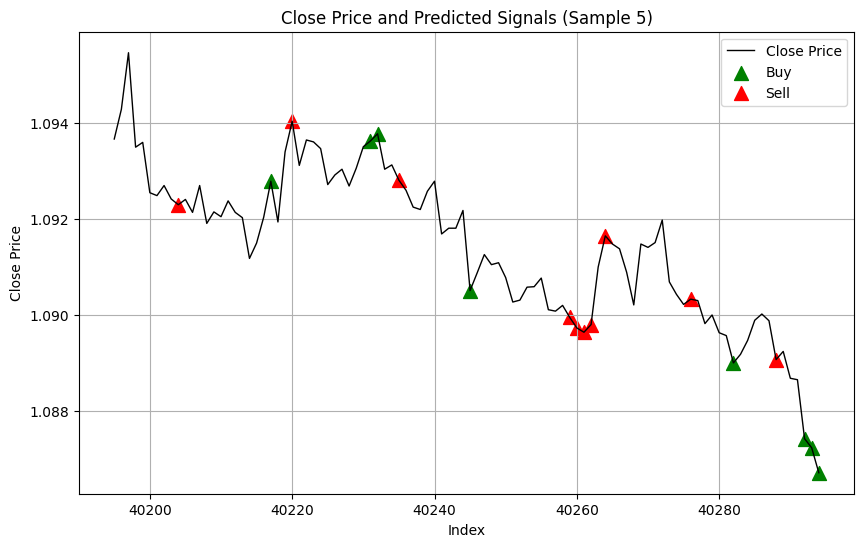

Plots saved as 'signal_plot_1.png' to 'signal_plot_5.png'


In [19]:
test_model_and_plot('/kaggle/input/testingg/USDCAD-60-DS.csv')

In [18]:
# نمایش اهمیت ویژگی‌ها
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print("\nFeature Importance:")
print(feature_importance)


Feature Importance:
       Feature  Importance
1          RSI    0.489284
7    macd_diff    0.200302
6     ema_diff    0.099060
4    macd_line    0.085686
5  macd_signal    0.044938
3        ema50    0.027355
2        ema20    0.027009
0        Close    0.026366


In [17]:
import pandas as pd
import pandas_ta as ta
import numpy as np
import matplotlib.pyplot as plt

def test_model_and_plot(csv_path):
    # خواندن دیتاست از فایل CSV
    data = pd.read_csv(csv_path)

    # بررسی مقادیر نامعتبر در ستون Close
    if not data['Close'].replace([np.inf, -np.inf], np.nan).notnull().all():
        print("Warning: Invalid values (inf or NaN) found in 'Close' column. Replacing with NaN...")
        data['Close'].replace([np.inf, -np.inf], np.nan, inplace=True)

    data['RSI'] = ta.rsi(data['Close'], length=14)
    data['sma10'] = ta.sma(data['Close'], length=10)
    data['sma50'] = ta.sma(data['Close'], length=50)
    macd = ta.macd(data['Close'], fast=12, slow=26, signal=9)
    data['macd_line'] = macd['MACD_12_26_9']
    data['macd_signal'] = macd['MACDs_12_26_9']
    data['macd_diff'] = data['macd_line'] - data['macd_signal']
    
    data['sma_diff'] = data['sma50'] - data['sma10']
    

    data.dropna(inplace=True)
    features = ['Close', 'RSI', 'sma10', 'sma50', 'macd_line', 'macd_signal', 'sma_diff', 'macd_diff']
    
    X = data[features]

    # پیش‌بینی سیگنال‌ها
    data['predicted_signal'] = xgb_model.predict(X)

    # انتخاب 5 دسته 100تایی متوالی به صورت رندوم
    max_start = len(data) - 100
    random_starts = np.random.choice(range(max_start), size=5, replace=False)

    # رسم 5 نمودار
    for i, start in enumerate(random_starts):
        end = start + 100
        subset = data.iloc[start:end]

        # ایجاد زیرنمودارها (3 ردیف: قیمت، RSI، MACD)
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True, 
                                             gridspec_kw={'height_ratios': [2, 1, 1], 'hspace': 0.05})

        # نمودار قیمت و EMA
        ax1.plot(subset.index, subset['Close'], label='Close Price', color='black')
        ax1.plot(subset.index, subset['sma10'], label='sma10', color='blue')
        ax1.plot(subset.index, subset['sma50'], label='sma50', color='orange')

        # رسم سیگنال‌ها با مثلث
        buy_signals = subset[subset['predicted_signal'] == 2]  # Buy
        sell_signals = subset[subset['predicted_signal'] == 0]  # Sell

        ax1.scatter(buy_signals.index, buy_signals['Close'], marker='^', color='green', label='Buy', s=100)
        ax1.scatter(sell_signals.index, sell_signals['Close'], marker='v', color='red', label='Sell', s=100)

        ax1.set_title(f'Close Price, EMA, RSI, MACD, and Predicted Signals (Sample {i+1})')
        ax1.set_ylabel('Price')
        ax1.legend()
        ax1.grid(True)

        # نمودار RSI
        ax2.plot(subset.index, subset['RSI'], label='RSI', color='purple')
        ax2.axhline(y=70, color='red', linestyle='--')
        ax2.axhline(y=30, color='green', linestyle='--')
        ax2.set_ylabel('RSI')
        ax2.legend()
        ax2.grid(True)

        # نمودار MACD
        ax3.plot(subset.index, subset['macd_line'], label='MACD Line', color='blue')
        ax3.plot(subset.index, subset['macd_signal'], label='MACD Signal', color='orange')
        ax3.set_xlabel('Index')
        ax3.set_ylabel('MACD')
        ax3.legend()
        ax3.grid(True)

        plt.show()


    print("Plots saved as 'signal_plot_1.png' to 'signal_plot_5.png'. You can download them from Kaggle output.")

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


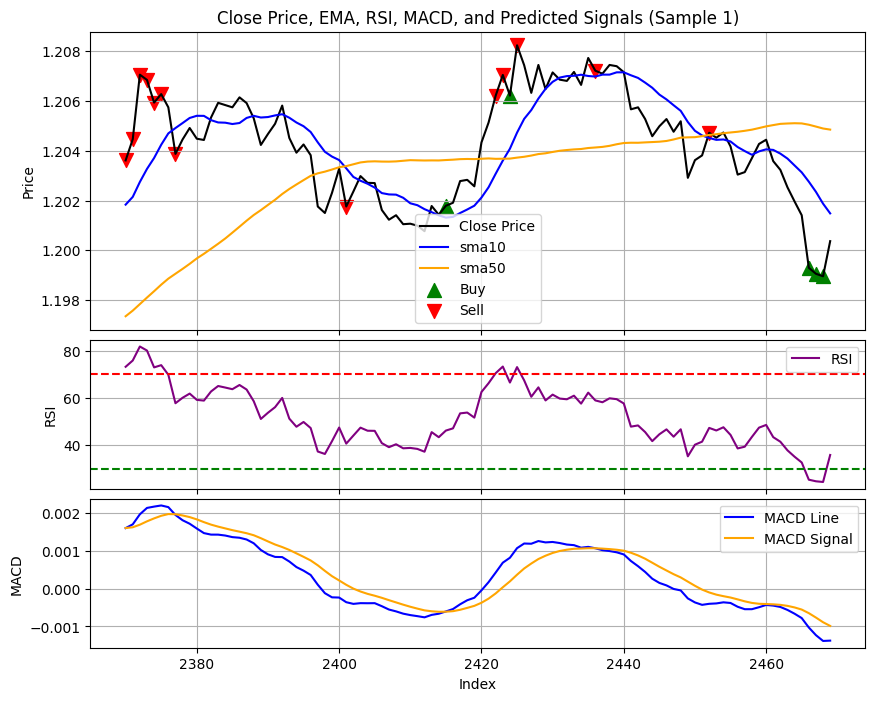

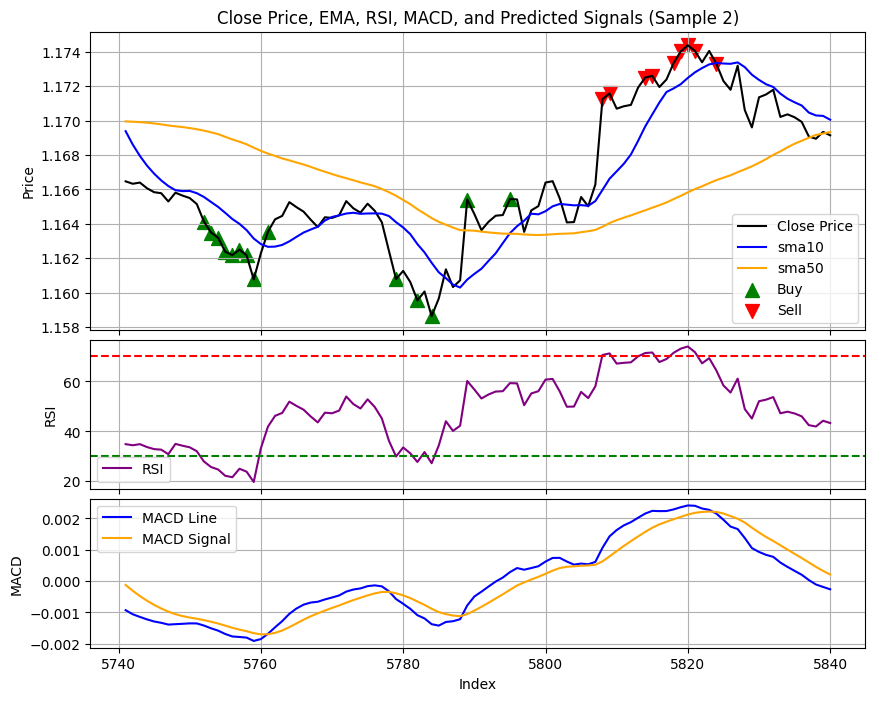

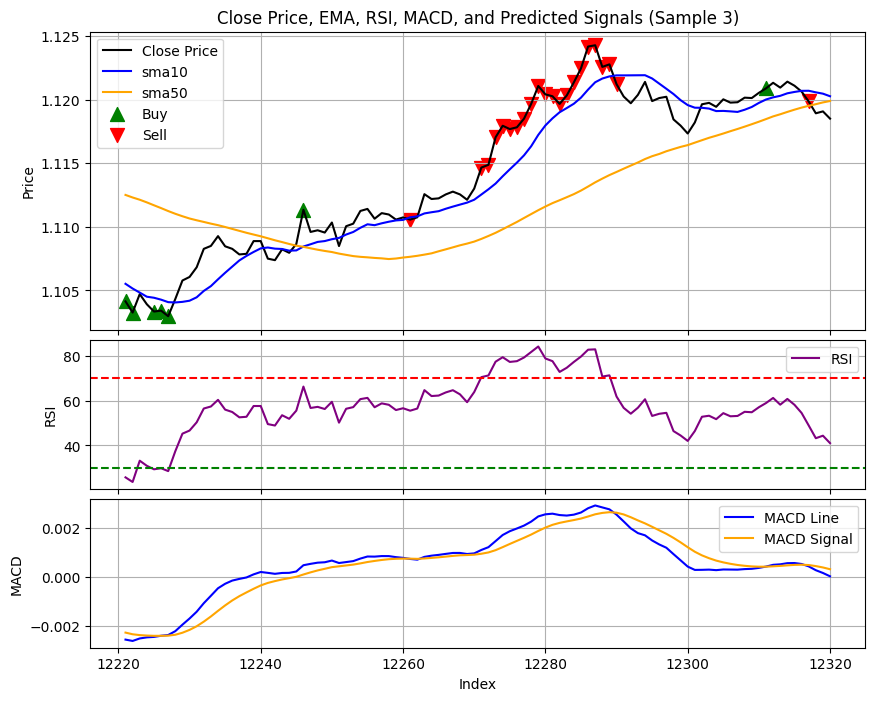

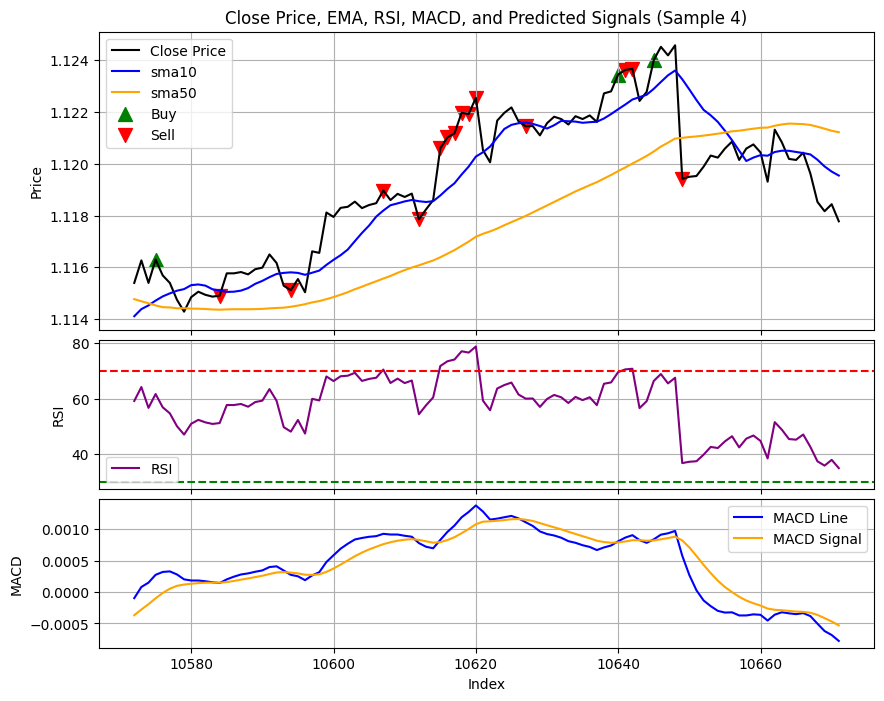

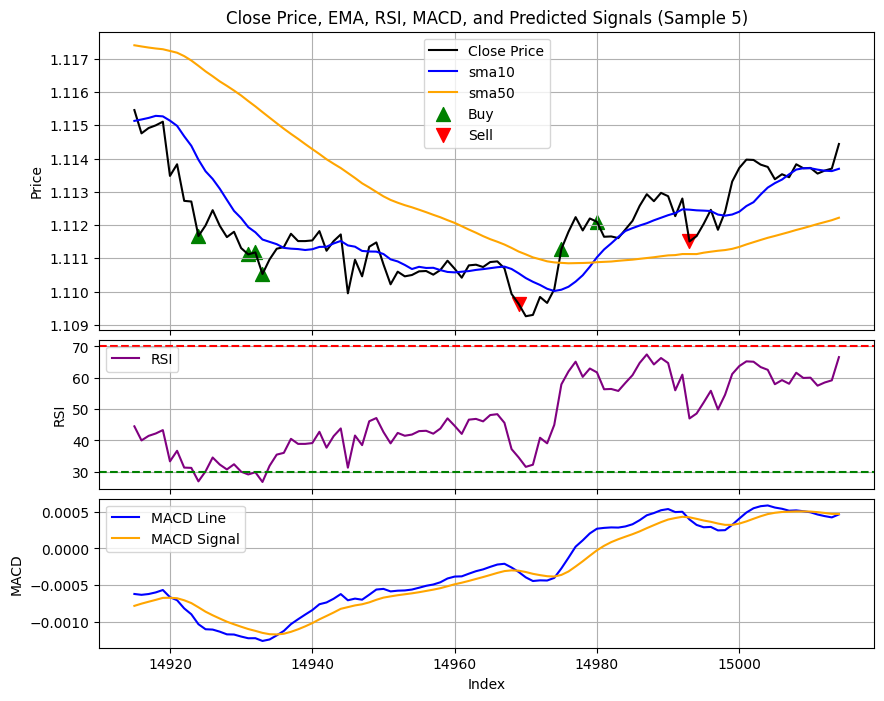

Plots saved as 'signal_plot_1.png' to 'signal_plot_5.png'. You can download them from Kaggle output.


In [18]:
test_model_and_plot('/kaggle/input/eurusd60/EURUSD-60-DS-redate.csv')

In [ ]:
x